In [3]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


def clean_text(text: str) -> str:
    """
    Basic text cleaning:
    - lowercase
    - remove escaped newline markers
    - keep letters/numbers/spaces only
    - collapse multiple spaces
    """
    text = str(text).lower()
    text = text.replace("\\n", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def load_and_vectorise(filepath: str):
    """
    Load the tab-separated dataset and convert the Sentence column into TF-IDF features.
    Returns:
        data        : original dataframe
        cleaned     : cleaned text series
        X           : TF-IDF feature matrix
        vectorizer  : fitted TF-IDF vectorizer
    """
    data = pd.read_csv(filepath, sep="\t")

    if "Sentence" not in data.columns:
        raise ValueError("Input file must contain a 'Sentence' column.")

    cleaned = data["Sentence"].fillna("").apply(clean_text)

    vectorizer = TfidfVectorizer(
        stop_words="english",
        lowercase=False  # already lowercased in clean_text
    )

    X = vectorizer.fit_transform(cleaned)

    return data, cleaned, X, vectorizer

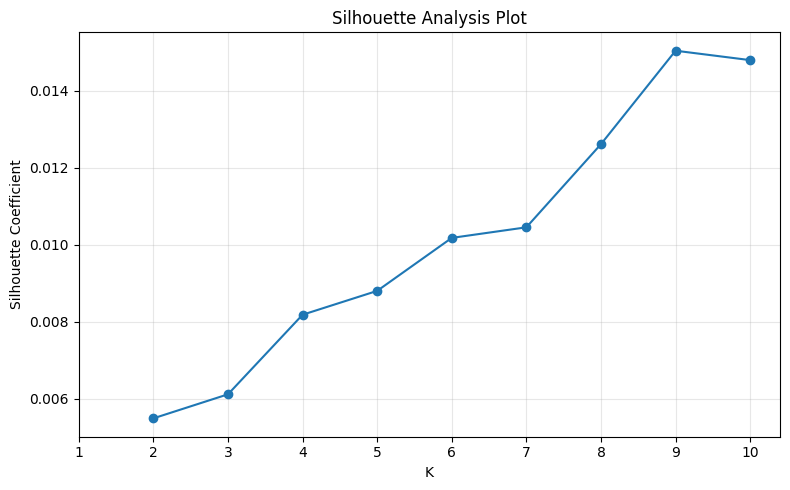

Best K: 9
Best silhouette score: 0.015041
Files created: label.txt, silhouette_plot.png


In [6]:
import sys
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def clean_text(text: str) -> str:
    """
    Clean raw text before vectorisation.
    """
    text = str(text).lower()
    text = text.replace("\\n", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def main():
    # Assignment requires the script to run like:
    # python clustering.py data.txt
    if len(sys.argv) < 2:
        print("Usage: python clustering.py <data_file>")
        sys.exit(1)

    filepath = r"C:\Users\kassi\Downloads\data_train.txt"

    # Load tab-separated file
    data = pd.read_csv(filepath, sep="\t")

    # Check expected column exists
    if "Sentence" not in data.columns:
        raise ValueError("Input file must contain a 'Sentence' column.")

    # Preprocess the text
    sentences = data["Sentence"].fillna("").apply(clean_text)

    # Convert text into TF-IDF vectors
    vectorizer = TfidfVectorizer(
        stop_words="english",
        lowercase=False  # already lowercased in clean_text
    )
    X = vectorizer.fit_transform(sentences)

    # Silhouette is not defined for K=1, so compute real scores for K=2..10
    tested_k = list(range(2, 11))
    silhouette_values = []

    for k in tested_k:
        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_values.append(score)

    # Choose the K with the highest silhouette score
    best_index = int(np.argmax(silhouette_values))
    best_k = tested_k[best_index]
    best_score = silhouette_values[best_index]

    # Train final model using best K
    final_model = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=10
    )
    final_labels = final_model.fit_predict(X)

    # Save labels exactly as required: one column, same order as input
    np.savetxt("label.txt", final_labels, fmt="%d")

    # Plot K=1..10, with K=1 marked as NaN because silhouette is undefined there
    plot_k = list(range(1, 11))
    plot_scores = [math.nan] + silhouette_values

    plt.figure(figsize=(8, 5))
    plt.plot(plot_k, plot_scores, marker="o")
    plt.xlabel("K")
    plt.ylabel("Silhouette Coefficient")
    plt.title("Silhouette Analysis Plot")
    plt.xticks(plot_k)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("silhouette_plot.png", dpi=300)
    plt.show()

    print(f"Best K: {best_k}")
    print(f"Best silhouette score: {best_score:.6f}")
    print("Files created: label.txt, silhouette_plot.png")


if __name__ == "__main__":
    main()